# Delhi Metro Network - Exploratory Data Analysis

Dataset used: **Delhi-Metro-Network.csv**  

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('Delhi-Metro-Network.csv', parse_dates=['Opening Date'])
df.drop_duplicates(subset=['Station Name'],inplace=True)
df.sample(n=5)

,Station ID,Station Name,Distance from Start (km),Line,Opening Date,Station Layout,Latitude,Longitude
259,260,Govind Puri,18.9,Voilet line,2010-03-10,Elevated,28.544510,77.264010
153,154,Dabri Mor - Janakpuri South,2.0,Magenta line,2018-05-29,Underground,28.615755,77.085178
206,207,Shastri Park,16.4,Red line,2002-12-25,Elevated,28.668000,77.249940
230,231,Shaheed Nagar,8.2,Red line,2019-08-03,Elevated,28.530780,77.212057
237,238,Shivaji Park,3.9,Green line,2010-02-04,Elevated,28.674900,77.130560


## 1. Basic Overview

In [11]:
df.columns

Index(['Station ID', 'Station Name', 'Distance from Start (km)', 'Line',
       'Opening Date', 'Station Layout', 'Latitude', 'Longitude'],
      dtype='object')

In [24]:
print(f'Total stations  : {df["Station Name"].nunique()}')
print(f'Number of lines : {df["Line"].nunique()}')
print(f'Lines Names     : {sorted(df["Line"].unique())}')
print(f'Date range      : {df["Opening Date"].min().date()} -> {df["Opening Date"].max().date()}')
print(f'Station layouts : {df["Station Layout"].unique()}')
print()
print("Data Information:")
print("-"*20)
df.info()

Total stations  : 283
Number of lines : 13
Lines Names     : ['Aqua line', 'Blue line', 'Blue line branch', 'Gray line', 'Green line', 'Green line branch', 'Magenta line', 'Orange line', 'Pink line', 'Rapid Metro', 'Red line', 'Voilet line', 'Yellow line']
Date range      : 2002-12-24 -> 2019-09-03
Station layouts : ['Elevated' 'Underground' 'At-Grade']

Data Information:
--------------------
<class 'pandas.core.frame.DataFrame'>
Index: 283 entries, 0 to 284
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Station ID                283 non-null    int64         
 1   Station Name              283 non-null    object        
 2   Distance from Start (km)  283 non-null    float64       
 3   Line                      283 non-null    object        
 4   Opening Date              283 non-null    datetime64[ns]
 5   Station Layout            283 non-null    object        
 6   Lati

In [25]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Station ID                  0
Station Name                0
Distance from Start (km)    0
Line                        0
Opening Date                0
Station Layout              0
Latitude                    0
Longitude                   0
dtype: int64


## 2. Stations per Line

Line
Blue line            48
Pink line            38
Yellow line          37
Voilet line          34
Red line             29
Magenta line         25
Aqua line            21
Green line           21
Rapid Metro          11
Blue line branch      8
Orange line           6
Gray line             3
Green line branch     2

Mean : 21.8
Std  : 15.0
Min  : 2 (Green line branch)
Max  : 48 (Blue line)


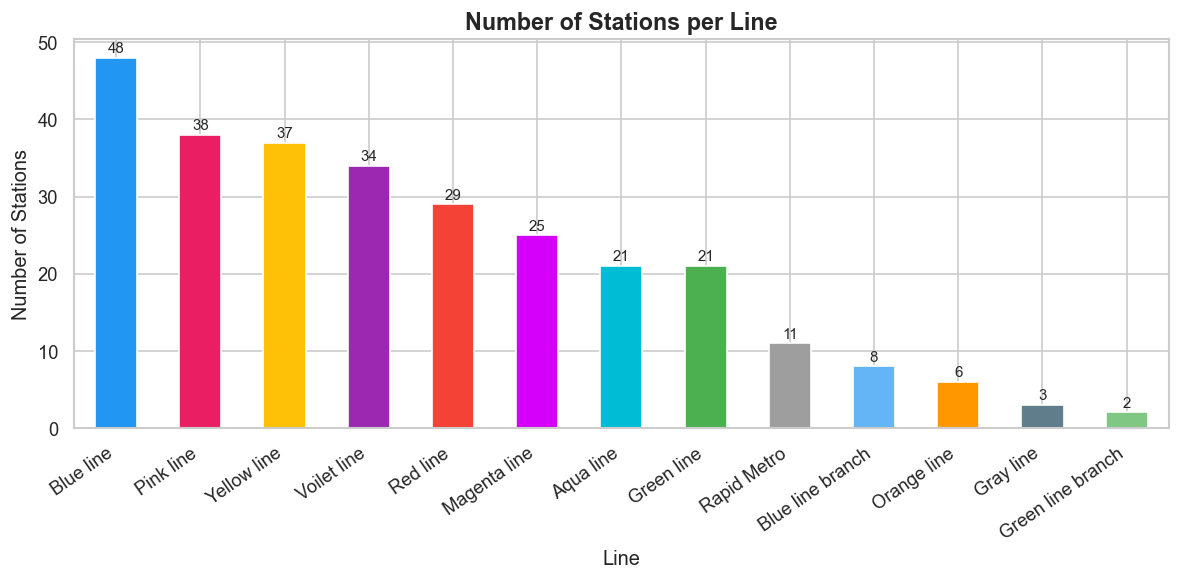

In [27]:
color_map = {
    'Blue line': '#2196F3',       # Blue
    'Pink line': '#E91E63',       # Vibrant pink
    'Yellow line': '#FFC107',     # Deep yellow/amber (better visibility than pure yellow)
    'Voilet line': '#9C27B0',     # Purple/Violet (matching the spelling in your data)
    'Red line': '#F44336',        # Red
    'Magenta line': '#D500F9',    # Magenta
    'Aqua line': '#00BCD4',       # Aqua/Cyan
    'Green line': '#4CAF50',      # Green
    'Rapid Metro': '#9E9E9E',     # Silver/Light Gray
    'Blue line branch': '#64B5F6',# Lighter blue for the branch
    'Orange line': '#FF9800',     # Orange
    'Gray line': '#607D8B',       # Dark gray
    'Green line branch': '#81C784'# Lighter green for the branch
}

stations_per_line = df.groupby('Line').size().sort_values(ascending=False)
print(stations_per_line.to_string())
print(f'\nMean : {stations_per_line.mean():.1f}')
print(f'Std  : {stations_per_line.std():.1f}')
print(f'Min  : {stations_per_line.min()} ({stations_per_line.idxmin()})')
print(f'Max  : {stations_per_line.max()} ({stations_per_line.idxmax()})')

fig, ax = plt.subplots(figsize=(10, 5))
colors = [color_map.get(line, '#CCCCCC') for line in stations_per_line.index]
stations_per_line.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Number of Stations per Line', fontsize=14, fontweight='bold')
ax.set_xlabel('Line')
ax.set_ylabel('Number of Stations')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            int(bar.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Line Lengths and Distance Distribution

Line lengths (km):
Line
Blue line            52.7
Pink line            52.6
Yellow line          45.7
Voilet line          43.5
Magenta line         33.1
Red line             32.7
Aqua line            27.1
Green line           24.8
Orange line          20.8
Rapid Metro          10.0
Blue line branch      8.1
Gray line             3.9
Green line branch     2.1

Mean line length : 27.5 km
Std  line length : 17.9 km
Min  line length : 2.1 km (Green line branch)
Max  line length : 52.7 km (Blue line)


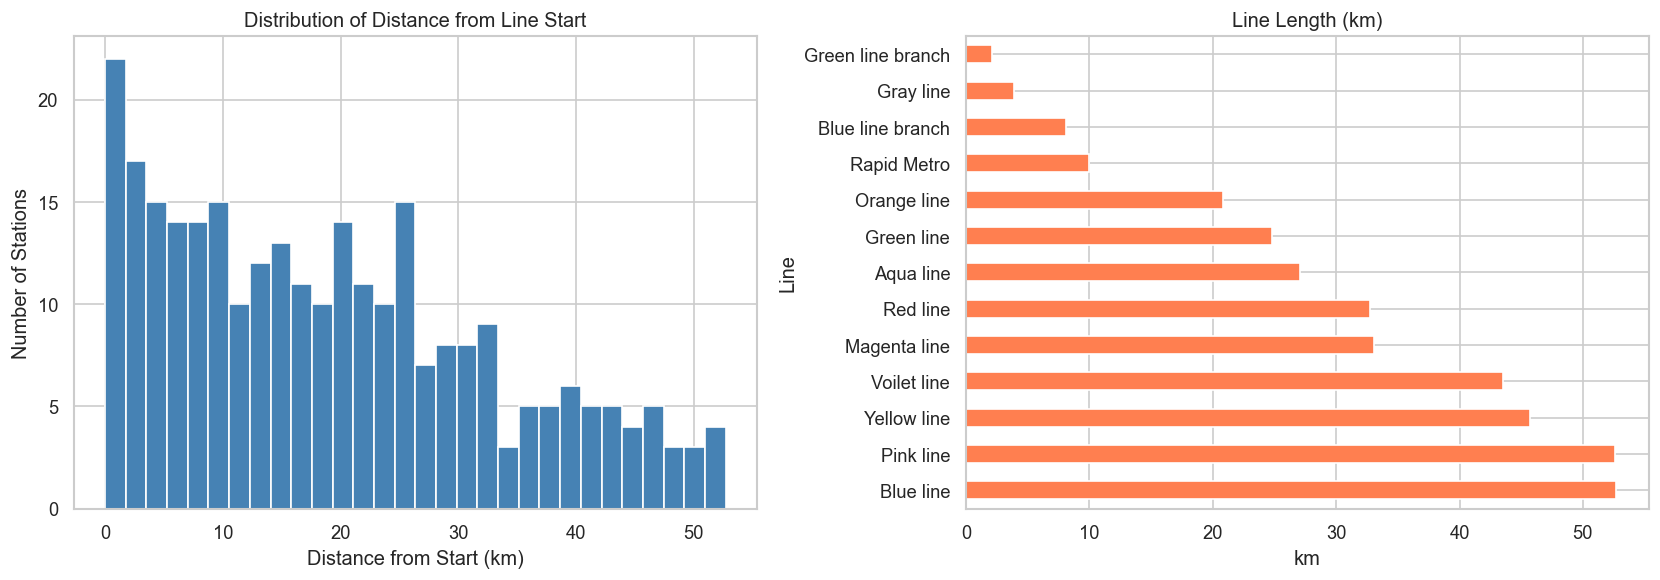

In [28]:
line_length = df.groupby('Line')['Distance from Start (km)'].max().sort_values(ascending=False)
print('Line lengths (km):')
print(line_length.to_string())
print(f'\nMean line length : {line_length.mean():.1f} km')
print(f'Std  line length : {line_length.std():.1f} km')
print(f'Min  line length : {line_length.min():.1f} km ({line_length.idxmin()})')
print(f'Max  line length : {line_length.max():.1f} km ({line_length.idxmax()})')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Distance from Start (km)'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Distance from Line Start')
axes[0].set_xlabel('Distance from Start (km)')
axes[0].set_ylabel('Number of Stations')
line_length.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Line Length (km)')
axes[1].set_xlabel('km')
plt.tight_layout()
plt.show()

## 4. Station Layout

Station Layout
Elevated       213
Underground     68
At-Grade         2

Proportion (%):
Station Layout
Elevated       75.3
Underground    24.0
At-Grade        0.7


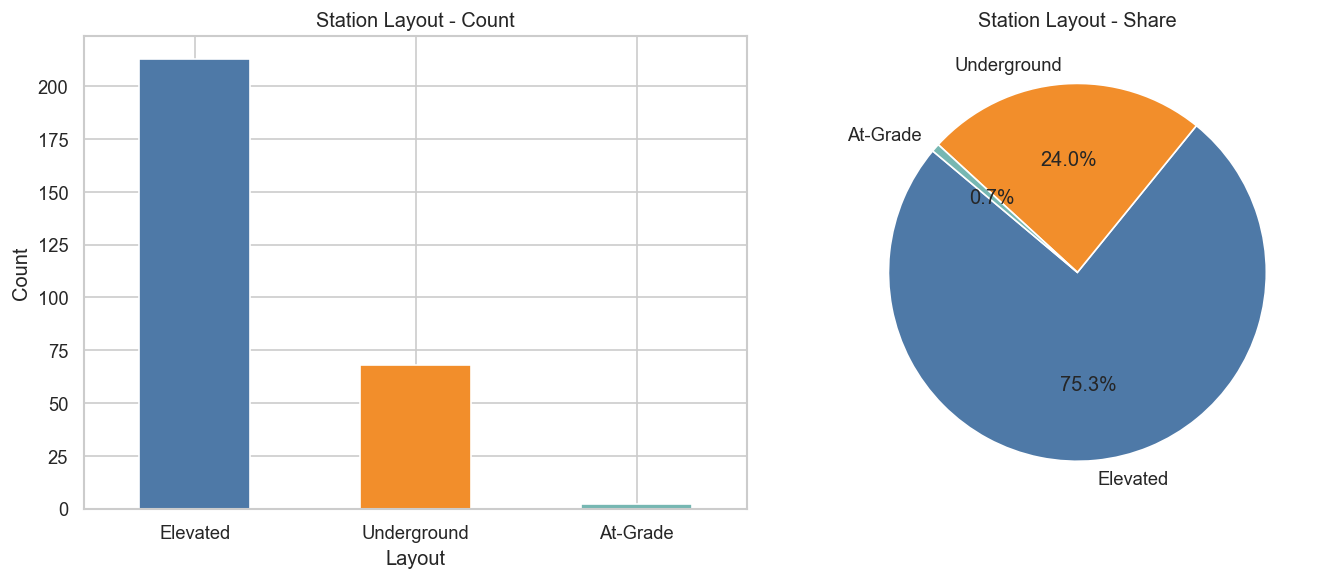

In [29]:
layout_counts = df['Station Layout'].value_counts()
print(layout_counts.to_string())
print('\nProportion (%):')
print((layout_counts / len(df) * 100).round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
layout_counts.plot(kind='bar', ax=axes[0],
                   color=['#4e79a7', '#f28e2b', '#76b7b2'], edgecolor='white')
axes[0].set_title('Station Layout - Count')
axes[0].set_xlabel('Layout')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[1].pie(layout_counts, labels=layout_counts.index, autopct='%1.1f%%',
            colors=['#4e79a7', '#f28e2b', '#76b7b2'], startangle=140)
axes[1].set_title('Station Layout - Share')
plt.tight_layout()
plt.show()

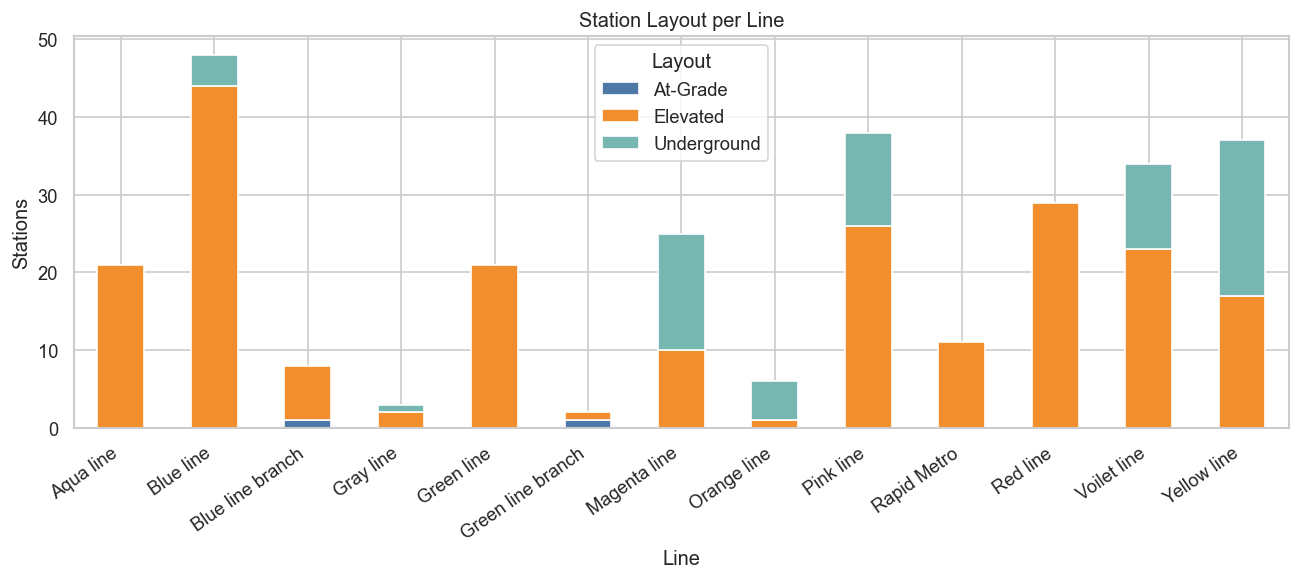

In [30]:
layout_by_line = df.groupby(['Line', 'Station Layout']).size().unstack(fill_value=0)
layout_by_line.plot(kind='bar', stacked=True, figsize=(11, 5),
                    color=['#4e79a7', '#f28e2b', '#76b7b2'], edgecolor='white')
plt.title('Station Layout per Line')
plt.xlabel('Line')
plt.ylabel('Stations')
plt.xticks(rotation=35, ha='right')
plt.legend(title='Layout')
plt.tight_layout()
plt.show()

## 5. Network Growth Over Time

Stations opened per year:
Year
2002     6
2003     4
2004    11
2005    28
2006     9
2008     3
2009    16
2010    53
2011    13
2013     5
2014     3
2015    13
2017    18
2018    64
2019    37

Year with most openings: 2018 (64 stations)


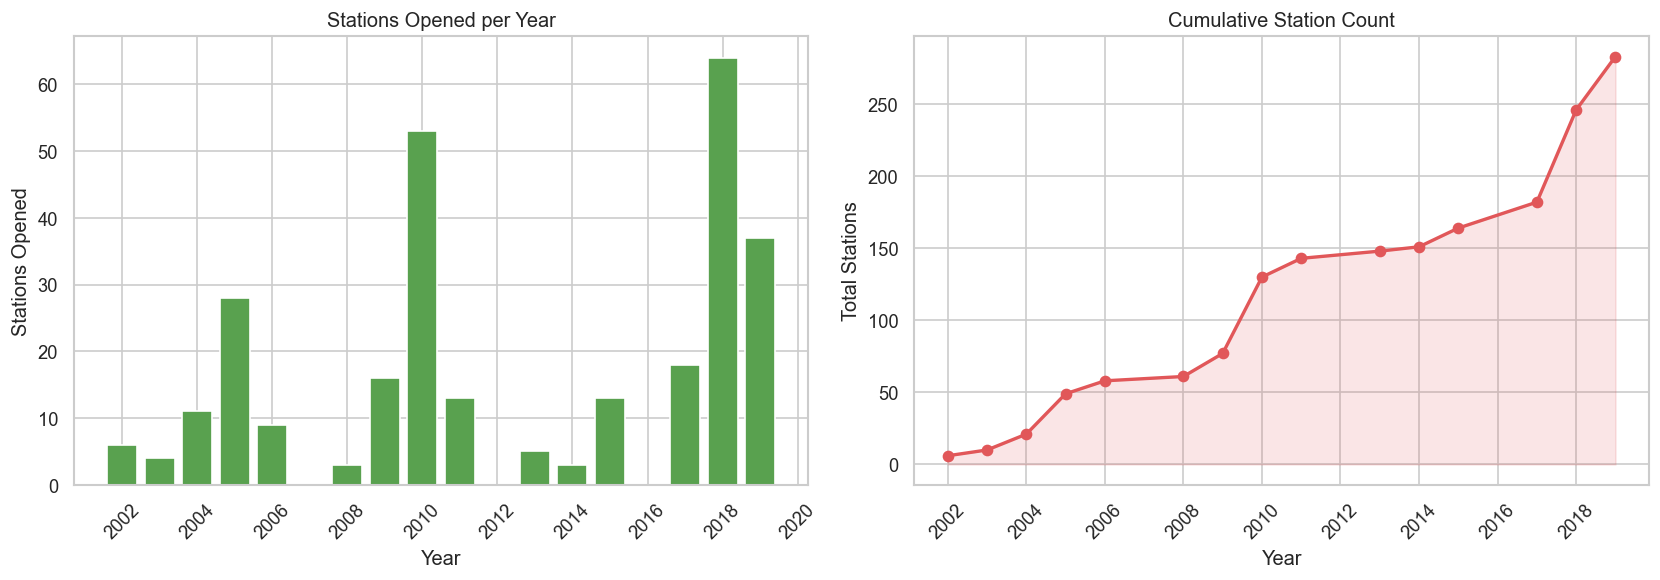

In [31]:
df['Year'] = df['Opening Date'].dt.year
stations_by_year = df.groupby('Year').size()
cumulative = stations_by_year.cumsum()

print('Stations opened per year:')
print(stations_by_year.to_string())
print(f'\nYear with most openings: {stations_by_year.idxmax()} ({stations_by_year.max()} stations)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(stations_by_year.index, stations_by_year.values, color='#59a14f', edgecolor='white')
axes[0].set_title('Stations Opened per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Stations Opened')
axes[0].xaxis.set_major_locator(ticker.MultipleLocator(2))
axes[0].tick_params(axis='x', rotation=45)
axes[1].plot(cumulative.index, cumulative.values, marker='o', color='#e15759', linewidth=2)
axes[1].fill_between(cumulative.index, cumulative.values, alpha=0.15, color='#e15759')
axes[1].set_title('Cumulative Station Count')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Stations')
axes[1].xaxis.set_major_locator(ticker.MultipleLocator(2))
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 6. Interchange Stations

In [32]:
df['is_interchange'] = df['Station Name'].str.contains(r'\[Conn:', na=False)
interchange = df[df['is_interchange']]

print(f'Total interchange stations : {len(interchange)}')
print(f'Total non-interchange       : {len(df) - len(interchange)}')
print(f'Interchange share           : {len(interchange) / len(df) * 100:.1f}%')
print()
print('Interchanges per line:')
print(interchange.groupby('Line').size().sort_values(ascending=False).to_string())

Total interchange stations : 50
Total non-interchange       : 233
Interchange share           : 17.7%

Interchanges per line:
Line
Blue line            10
Pink line            10
Yellow line           8
Voilet line           5
Magenta line          4
Red line              4
Orange line           3
Blue line branch      2
Aqua line             1
Gray line             1
Green line branch     1
Rapid Metro           1


## 7. Per-Line Summary Statistics

In [33]:
summary = df.groupby('Line').agg(
    num_stations=('Station ID', 'count'),
    line_length_km=('Distance from Start (km)', 'max'),
    avg_spacing_km=('Distance from Start (km)',
                    lambda x: round(x.max() / (len(x) - 1), 2) if len(x) > 1 else None),
    num_interchange=('is_interchange', 'sum'),
    first_opened=('Opening Date', 'min'),
    last_opened=('Opening Date', 'max'),
).sort_values('num_stations', ascending=False)

summary['first_opened'] = summary['first_opened'].dt.date
summary['last_opened']  = summary['last_opened'].dt.date
summary['line_length_km'] = summary['line_length_km'].round(1)
summary

,num_stations,line_length_km,avg_spacing_km,num_interchange,first_opened,last_opened
Line,,,,,,
Blue line,48,52.7,1.12,10,2005-12-30,2019-09-03
Pink line,38,52.6,1.42,10,2018-03-14,2018-12-31
Yellow line,37,45.7,1.27,8,2004-12-20,2015-10-11
Voilet line,34,43.5,1.32,5,2010-03-10,2018-11-19
Red line,29,32.7,1.17,4,2002-12-24,2019-08-03
Magenta line,25,33.1,1.38,4,2017-12-25,2018-05-29
Aqua line,21,27.1,1.35,1,2019-01-25,2019-01-25
Green line,21,24.8,1.24,0,2010-02-04,2018-06-24
Rapid Metro,11,10.0,1.00,1,2013-11-14,2017-04-25
